In [60]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/martanarozhnyak/py312/bin/python -m pip install --upgrade pip


In [61]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [62]:
#2. Import .csv file
df = pd.read_csv('/Users/martanarozhnyak/Desktop/Telco-Customer-Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [63]:
# 3. Preview the table: its size, whether it has null values, and data types.

print(df.shape)
df.info()
df.head()
## From the output below, we can see that this table has improperly assigned data types.

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [64]:
# 4. Fix data types

## Column TotalCharges has improperly assigned object data type 
## compared to the column MonthlyCharges that has the same information but a float64 data type

## 4.1 Check how many values are blank strings
print((df['TotalCharges'].str.strip() == '').sum())

## 4.2 See what those rows look like
df[df['TotalCharges'].str.strip() == '']

## From the output below, we can see that the customers with tenure == 0 signed up but were never billed. 
## That's why TotalCharges is blank, not missing at random.

11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [65]:
## 4.3 Replace blank strings with NaN, then convert to float
df['TotalCharges'] = df['TotalCharges'].str.strip().replace('', np.nan).astype(float)

print(df['TotalCharges'].isnull().sum())
print(df['TotalCharges'].dtype)

11
float64


In [66]:
## 4.4 Fill in 11 nulls in TotalCharges with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

## As such records have tenure == 0 and MonthlyCharges > 0, I decided don't drop them

In [67]:
# 5. Convert SeniorCitizen from 0/1 to Yes/No for consistency
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
df['SeniorCitizen'].value_counts()

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

In [68]:
# 6. Convert Churn to binary integer (1/0) for calculations
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [69]:
# Section 2: EDA

# 1. What is the overall churn rate?
churn_rate = df['Churn'].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

Overall churn rate: 26.5%


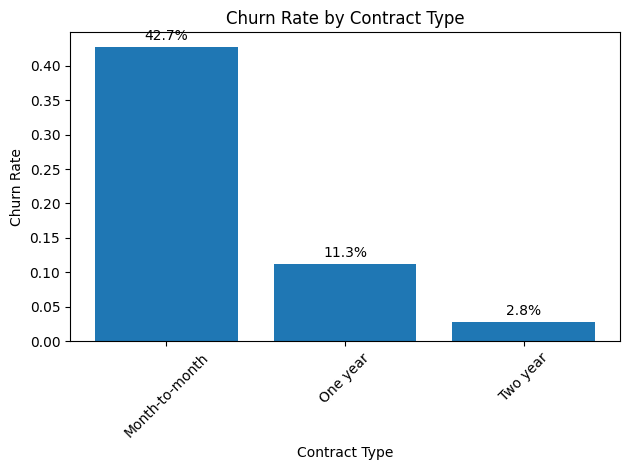

In [70]:
#2. How does churn rate vary by contract type? 

## Creating bar chart
churn_by_contract = df.groupby('Contract')['Churn'].mean()

plt.figure()
plt.bar(churn_by_contract.index, churn_by_contract.values)
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=45)
## Add percentage labels on top of each bar
for i, v in enumerate(churn_by_contract.values):
    plt.text(i, v + 0.01, f"{v:.1%}", ha='center')
plt.tight_layout()
plt.show()

## From the output below, we can see that Month-to-month customers churn at 42.7% vs 11.3% for one-year and 2.8% for two-year contracts.

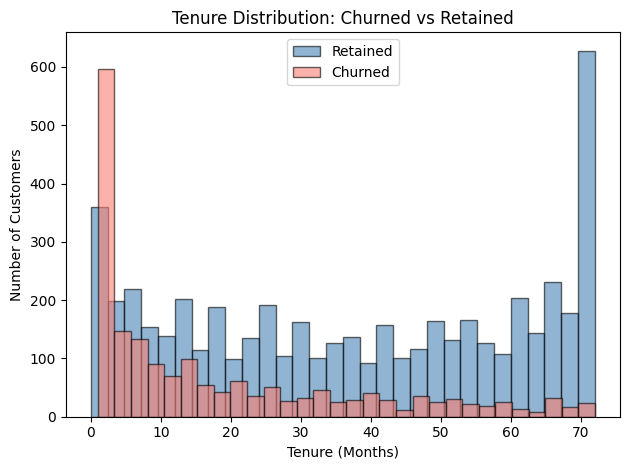

In [71]:
# 3. How does tenure relate to churn? 

churned = df[df['Churn'] == 1]['tenure']
retained = df[df['Churn'] == 0]['tenure']

## Creating the histogram
plt.figure()
plt.hist(retained, bins=30, alpha=0.6, label='Retained', color='steelblue', edgecolor='black')
plt.hist(churned, bins=30, alpha=0.6, label='Churned', color='salmon', edgecolor='black')

## Adding labels and title
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.title('Tenure Distribution: Churned vs Retained')
plt.legend()
plt.tight_layout()

## Show the plot
plt.show()


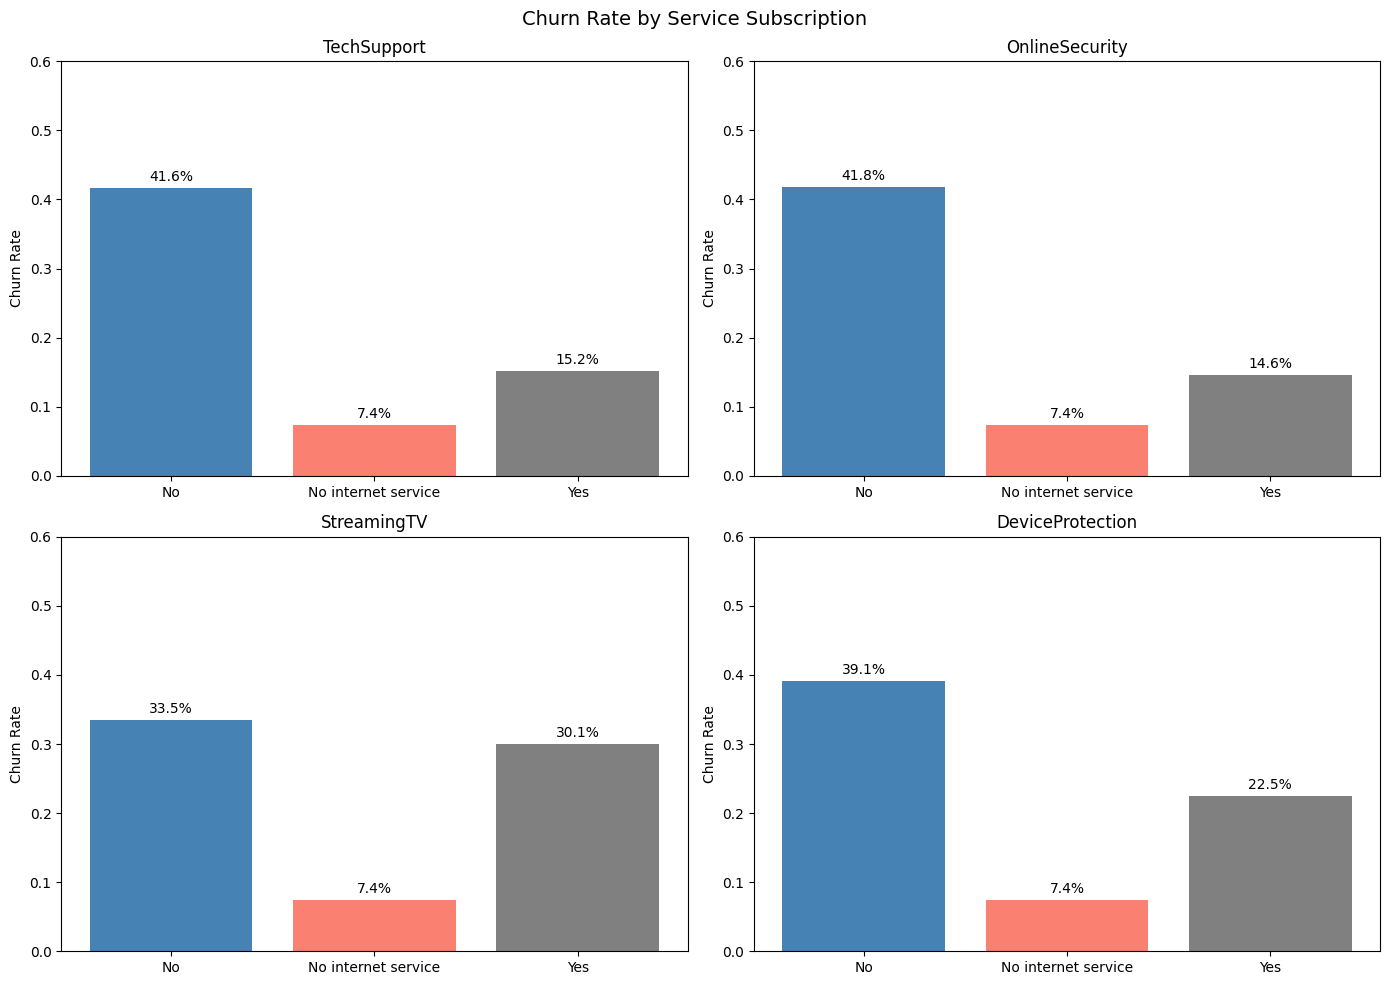

In [72]:
# 4. Which services correlate most strongly with churn?

## Define the service columns to analyze
services = ['TechSupport', 'OnlineSecurity', 'StreamingTV', 'DeviceProtection']

## Calculate churn rate for each subscription status (Yes / No / No internet service)
## per service and store results in a dictionary
churn_rates = {}
for service in services:
    rate = df.groupby(service)['Churn'].mean()
    churn_rates[service] = rate

## Creating a 2x2 grid — one subplot per service
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
## flatten() converts the 2x2 array of axes into a flat list so we can loop over it easily
axes = axes.flatten()

for ax, service in zip(axes, services):
    data = churn_rates[service]
    ## Bar colors: steelblue = No, salmon = No internet service, gray = Yes
    ax.bar(data.index, data.values, color=['steelblue', 'salmon', 'gray'])
    ax.set_title(service)
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel('')
    ## Fix y-axis at 0–60% so all four charts are directly comparable
    ax.set_ylim(0, 0.6)
    ## Adding percentage label on top of each bar
    for i, v in enumerate(data.values):
        ax.text(i, v + 0.01, f"{v:.1%}", ha='center')

plt.suptitle('Churn Rate by Service Subscription', fontsize=14)
plt.tight_layout()
plt.show()

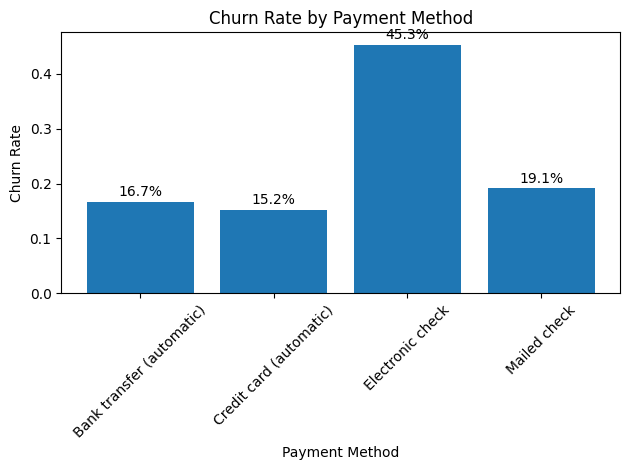

In [73]:
# 5. What's the churn rate by payment method?

## Creating bar chart
churn_by_paymentmethod = df.groupby('PaymentMethod')['Churn'].mean()

plt.figure()
plt.bar(churn_by_paymentmethod.index, churn_by_paymentmethod.values)
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=45)
## Add percentage labels on top of each bar
for i, v in enumerate(churn_by_paymentmethod.values):
    plt.text(i, v + 0.01, f"{v:.1%}", ha='center')
plt.tight_layout()
plt.show()

## Electronic check customers churn at 45.3%, nearly 3× higher than credit card (15.2%) 
## and bank transfer (16.7%) automatic payment methods. Manual payment methods 
## (electronic and mailed check) show higher churn, suggesting these customers 
## have weaker commitment or a more friction-prone experience.

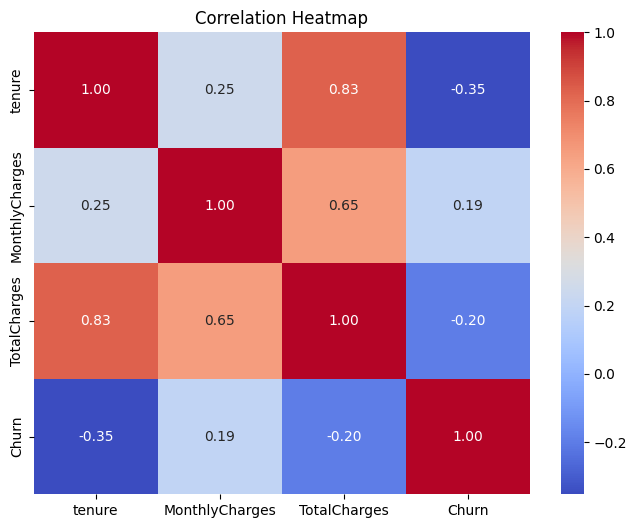

In [74]:
# 6. Correlation heatmap of numeric variables (tenure, MonthlyCharges, TotalCharges vs churn)

## Calculate the correlation matrix
## Only includes numerical columns by default
corr_matrix = df.corr(numeric_only=True)

## Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## Tenure shows the strongest relationship with churn (-0.35): customers who stay longer 
## are significantly less likely to leave. MonthlyCharges has a weak positive correlation 
## (0.19), suggesting price sensitivity plays a minor role. TotalCharges (-0.20) largely 
## mirrors tenure and should not be treated as an independent churn signal.
## Note: tenure and TotalCharges are strongly correlated (0.83), which is expected — 
## longer customers simply accumulate more total spend.